In [1]:
import os; os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='1.' # NOTE: jax preallocates GPU (default 75%)
from pathlib import Path
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
from jax import numpy as jnp, random as jr, config as jconfig, devices as jdevices, jit, vmap, pmap, grad, debug, tree, lax, value_and_grad
jconfig.update("jax_enable_x64", True)
print(jdevices())

%matplotlib inline
%load_ext autoreload
%autoreload 2
!hostname
#!jupyter nbconvert --to python /dvs_ro/u1/h/hsimfroy/workspace/montecosmo_proj/src/montecosmo/tests/infer_model2.ipynb

# save_dir = Path("./save/")
# save_dir = Path(os.path.expanduser("~/scratch/png/abacus_c0_i0_z08_lrg/test")) # FMN
# load_dir = Path(os.path.expanduser("~/scratch/png/abacus_c0_i0_z08_lrg/load/")) # FMN
# save_dir = Path("/lustre/fsn1/projects/rech/fvg/uvs19wt/png/") # JZ
# save_dir = Path("/lustre/fswork/projects/rech/fvg/uvs19wt/workspace/png/") # JZ
save_dir = Path("/pscratch/sd/h/hsimfroy/png/abacus_c0_i0_z0.8_lrg/noise") # Perlmutter
# load_dir = Path("/pscratch/sd/h/hsimfroy/png/abacus_c0_i0_z0.8_lrg/load/") # Perlmutter
load_dir = Path("/pscratch/sd/h/hsimfroy/png/fpm_b2760_z1_lrg_fNL/load/") # Perlmutter
# save_path = save_dir / "test"
save_dir.mkdir(parents=True, exist_ok=True)


# Make a LaTeX install available for matplotlib usetex=True (NERSC texlive module).
import shutil
if shutil.which('latex') is None:
    texbin = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux"
    if os.path.isdir(texbin):
        os.environ['PATH'] = texbin + os.pathsep + os.environ['PATH']


[CudaDevice(id=0)]


/global/homes/h/hsimfroy/miniforge3/envs/montenv/lib/python3.14/pty.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


login02


## Comparison with Power Spectrum

### FPM

In [ ]:
from getdist import plots, loadMCSamples
from montecosmo.plot import SetDark2, theme
from montecosmo.utils import pload
labels = 3*["$f_{NL}=-100$", "$f_{NL}=0$", "$f_{NL}=100$"]
# labels = ["2LPT $f_{NL}=-100$", "2LPT $f_{NL}=0$", "2LPT $f_{NL}=100$"]
# labels += ["Kaiser $f_{NL}=-100$", "Kaiser $f_{NL}=0$", "Kaiser $f_{NL}=100$"]
gdsamps = []


theme(usetex=True, font_size=16)

fli_root = Path("/pscratch/sd/h/hsimfroy/png/fpm_b2760_z1_lrg_fNL/tracer_fpmred_eh0_ovsamp2_s80_fNLb/")
# fli_root = Path("/pscratch/sd/h/hsimfroy/png/fpm_b2760_z1_lrg_fNL/tracer_fpmred_eh0_ovsamp2_s80_fNLb_old/")
folders = [
        #     "lpt_64_fNL-100",
        #    "lpt_64_fNL0",
        #    "lpt_64_fNL100",
            "lpt_32_fNL-100_noiseb30",
           "lpt_32_fNL0_noiseb30",
           "lpt_32_fNL100_noiseb30",
        #     "lpt_32_fNL-100_fourier_noise0",
        #    "lpt_32_fNL0_fourier_noise0",
        #    "lpt_32_fNL100_fourier_noise0",
           ]
# gdsamps = []
for folder, label in zip(folders, labels):
    chains = pload(fli_root / folder / "chains/chains.p")
    print('\n', chains.shape)
    chains['bfnl_loc'] = chains.pop("fNL_bp")
    chains['b1'] = chains['b1'] + 1
    gdsamp = chains.prune()[['b1','bfnl_loc']].to_getdist(label)
    # gdsamp = chains.prune()[['b1','fNL_bp']].to_getdist(label)
    par = gdsamp.getParamNames().parWithName('bfnl_loc')
    par.label = r'{f}_\mathrm{NL} b_\phi'
    gdsamps.append(gdsamp)

pow_root = Path("/pscratch/sd/a/adematti/desi-fnl-standard-analysis/")
folders = [
        "run-knl-fnl--100-a0.5000",
        "run-knl-fnl-0-a0.5000",
        "run-knl-fnl-100-a0.5000",
        ]
for folder in folders:
    pow_path = pow_root / folder / "mcmc_getdist_mcut2.25e+12_nbar1.00e-04_los-z/"
    gdsamp = loadMCSamples(str(pow_path))
    par = gdsamp.getParamNames().parWithName('bfnl_loc')
    # par.name = 'fNL_bp'
    par.label = r'{f}_\mathrm{NL} b_\phi'

    print(gdsamp.getParamNames().list())
    gdsamps.append(gdsamp)


 {'b1': (4, 2048), 'b2': (4, 2048), 'bn2': (4, 2048), 'bnpar': (4, 2048), 'bs2': (4, 2048), 'fNL': (4, 2048), 'fNL_bp': (4, 2048), 'fNL_bpd': (4, 2048), 'init_mesh': (4, 2048, 10), 'kptc': ((4, 2048, 23), (4, 2048, 23), (4, 2048, 23), (4, 2048, 23)), 'logdensity': (4, 2048), 'mse_per_dim': (4, 2048), 'n_evals': (4, 2048), 'ngbars': (4, 2048, 1)}
Removed no burn in

 {'b1': (4, 2048), 'b2': (4, 2048), 'bn2': (4, 2048), 'bnpar': (4, 2048), 'bs2': (4, 2048), 'fNL': (4, 2048), 'fNL_bp': (4, 2048), 'fNL_bpd': (4, 2048), 'init_mesh': (4, 2048, 10), 'kptc': ((4, 2048, 23), (4, 2048, 23), (4, 2048, 23), (4, 2048, 23)), 'logdensity': (4, 2048), 'mse_per_dim': (4, 2048), 'n_evals': (4, 2048), 'ngbars': (4, 2048, 1)}
Removed no burn in

 {'b1': (4, 2048), 'b2': (4, 2048), 'bn2': (4, 2048), 'bnpar': (4, 2048), 'bs2': (4, 2048), 'fNL': (4, 2048), 'fNL_bp': (4, 2048), 'fNL_bpd': (4, 2048), 'init_mesh': (4, 2048, 10), 'kptc': ((4, 2048, 23), (4, 2048, 23), (4, 2048, 23), (4, 2048, 23)), 'logdensity'

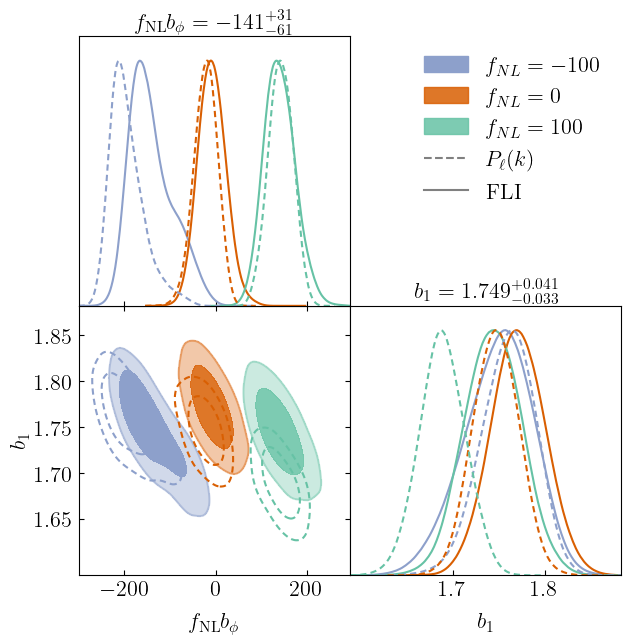

In [7]:

gdplt = plots.get_subplot_plotter(width_inch=7, scaling=False, rc_sizes=True)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels[:3],
                title_limit=1,
                filled=3*[True]+3*[False]+3*[False]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=4*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*['--']+3*['--']+3*['-.'],
                contour_lws=3*[1.5]+3*[1.5]+3*[1.5]+3*[1.5],
                )

# Append grey style entries (linestyle = method) to the existing colored legend (color = f_NL).
from matplotlib.lines import Line2D
from matplotlib.transforms import IdentityTransform
leg = gdplt.legend
handles = list(leg.legend_handles)
texts = [t.get_text() for t in leg.get_texts()]
handles += [Line2D([], [], color='grey', ls='--', lw=1.5),
            Line2D([], [], color='grey', ls='-',  lw=1.5)]
texts += [r'$P_\ell(k)$', 'FLI']
loc, bbox, fs = leg._loc, leg.get_bbox_to_anchor(), leg.get_texts()[0].get_fontsize()
leg.remove()
gdplt.fig.legend(handles, texts, loc=loc, bbox_to_anchor=bbox,
                 bbox_transform=IdentityTransform(), prop={'size': fs}, frameon=False)

# gdplt.export(str(save_dir / "fnl_bphi_fli_pell.pdf"))


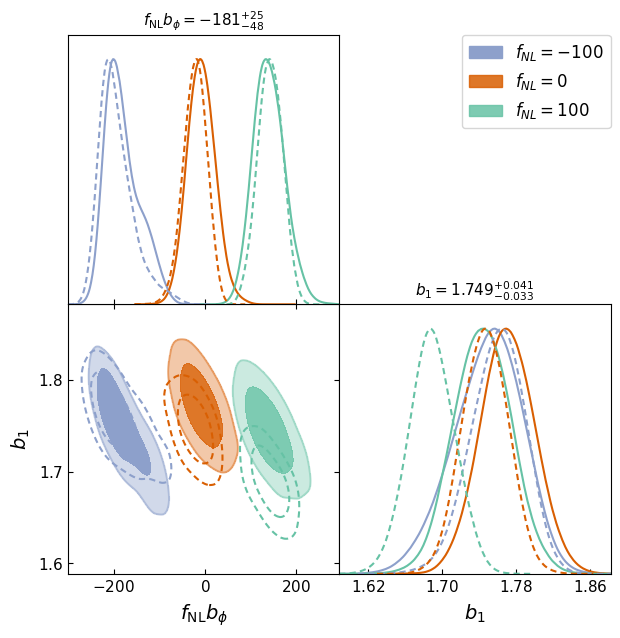

In [ ]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels[:3],
                title_limit=1,
                filled=3*[True]+3*[False]+3*[False]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=4*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*['--']+3*['--']+3*['-.'],
                contour_lws=3*[1.5]+3*[1.5]+3*[1.5]+3*[1.5],
                )


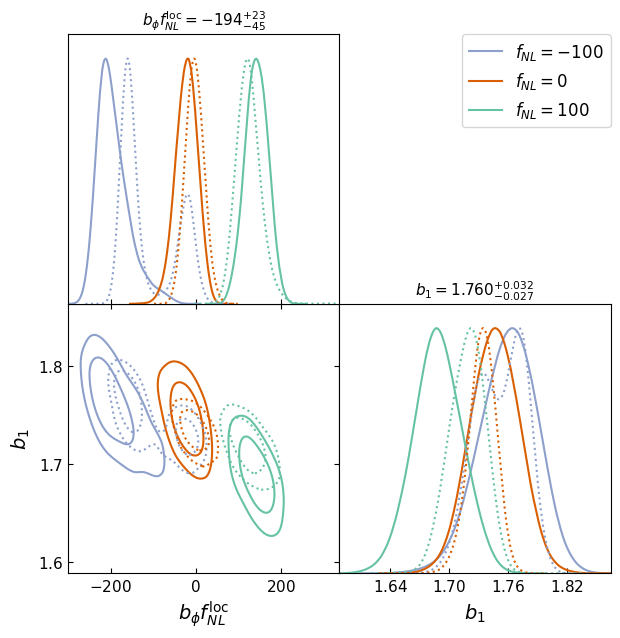

In [ ]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels[:3],
                title_limit=1,
                filled=3*[False]+3*[False]+3*[False]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=4*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*[':']+3*['--']+3*['-.'],
                contour_lws=3*[1.5]+3*[1.5]+3*[1.5]+3*[1.5],
                )

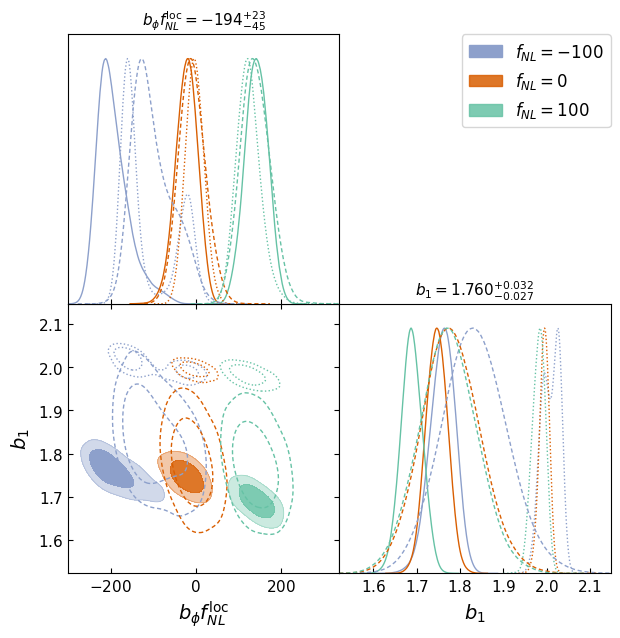

In [ ]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels[:3],
                title_limit=1,
                filled=3*[True]+3*[False]+3*[False]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=4*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*[':']+3*['--']+3*['-.'],)

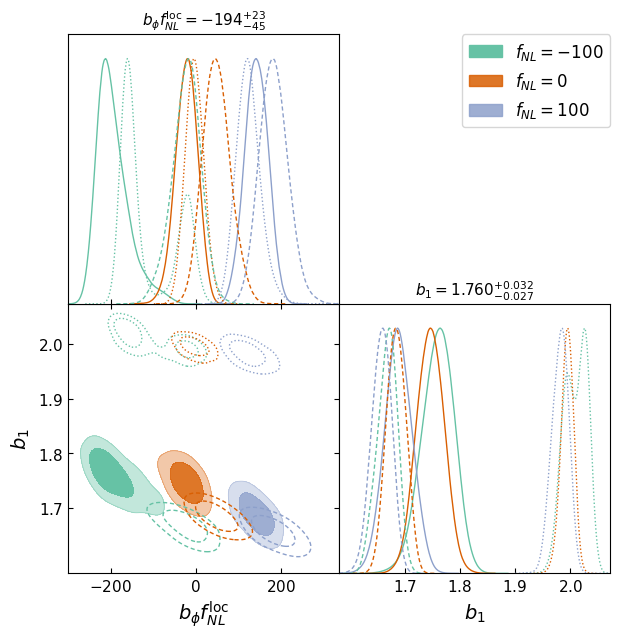

In [ ]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels[:3],
                title_limit=1,
                filled=3*[True]+3*[False]+3*[False]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=4*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*[':']+3*['--']+3*['-.'],)

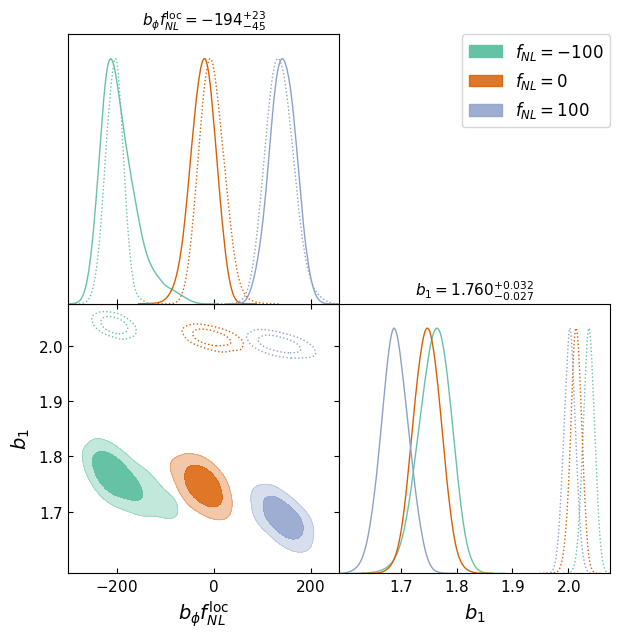

In [ ]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels,
                title_limit=1,
                filled=3*[True]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=2*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*[':'],)

In [14]:
delta_c = 1.686
b1 = 0.7
fNL_bp = 230
fNL = 100
bp = 2*delta_c*(b1 + 1 - 1)
ps = b1 + 1 - fNL_bp / (fNL * 2 * delta_c)
bp, ps

(2.3604, 1.0179122182680902)

In [ ]:
delta_c = 1.686
b1 = 0.75
fNL_bp = 50
fNL = 100
bp = 2*delta_c*(b1 +1 - 1.6)
ps = b1 + 1 - fNL_bp / (fNL * 2 * delta_c)
bp, ps

(1.3487999999999996, 1.8517200474495847)

### Abacus

In [10]:
from getdist import plots, loadMCSamples
from montecosmo.plot import SetDark2, theme
from montecosmo.utils import pload
labels = ["Pow", "FLI 32", "FLI 64"]
pow_root = Path("/pscratch/sd/a/adematti/desi-fnl-standard-analysis/")
folders = ["abacus-fnl-0-z0.8000",]
gdsamps = []
for folder in folders:
    pow_path = pow_root / folder / "mcmc_getdist_los-z/"
    gdsamp = loadMCSamples(str(pow_path))
    print(gdsamp.getParamNames().list())
    gdsamps.append(gdsamp)


fli_root = Path("/pscratch/sd/h/hsimfroy/png/abacus_c0_i0_z0.8_lrg/tracer_rsdflat_eh0_ovsamp2_s80_fNLb/")
folders = ["lpt_32_fNL0_fourier",
           "lpt_64_fNL0_fourier"]
# gdsamps = []
for folder, label in zip(folders, labels):
    chains = pload(fli_root / folder / "chains/chains.p")
    print('\n', chains.shape)
    # chains['bfnl_loc'] = -4*chains.pop("fNL_bp")
    chains['bfnl_loc'] = chains.pop("fNL_bp")
    chains['b1'] = chains['b1'] + 1
    gdsamp = chains.prune()[['b1','bfnl_loc']].to_getdist(label)
    gdsamps.append(gdsamp)

['bfnl_loc', 'b1', 'sn0', 'sigmas', 'logposterior', 'loglikelihood', 'logprior']

 {'b1': (4, 2048), 'b2': (4, 2048), 'bn2': (4, 2048), 'bnpar': (4, 2048), 'bs2': (4, 2048), 'fNL': (4, 2048), 'fNL_bp': (4, 2048), 'fNL_bpd': (4, 2048), 'init_mesh': (4, 2048, 10), 'kptc': ((4, 2048, 23), (4, 2048, 23), (4, 2048, 23), (4, 2048, 23)), 'logdensity': (4, 2048), 'mse_per_dim': (4, 2048), 'n_evals': (4, 2048), 'ngbars': (4, 2048, 1), 's_e': (4, 2048), 's_k2e': (4, 2048), 's_kmu2e': (4, 2048)}
Removed no burn in

 {'b1': (4, 1024), 'b2': (4, 1024), 'bn2': (4, 1024), 'bnpar': (4, 1024), 'bs2': (4, 1024), 'fNL': (4, 1024), 'fNL_bp': (4, 1024), 'fNL_bpd': (4, 1024), 'init_mesh': (4, 1024, 10), 'kptc': ((4, 1024, 47), (4, 1024, 47), (4, 1024, 47), (4, 1024, 47)), 'logdensity': (4, 1024), 'mse_per_dim': (4, 1024), 'n_evals': (4, 1024), 'ngbars': (4, 1024, 1), 's_e': (4, 1024), 's_k2e': (4, 1024), 's_kmu2e': (4, 1024)}
Removed no burn in


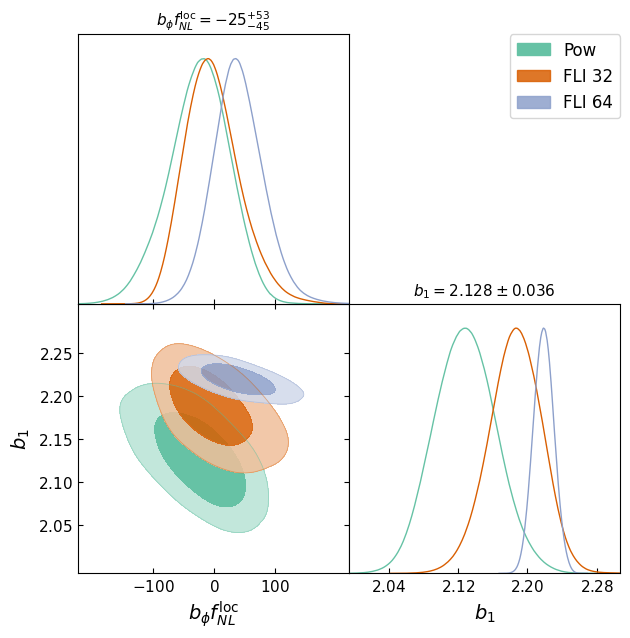

In [14]:
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=gdsamps,
                params=['bfnl_loc', 'b1'],
                legend_labels=labels,
                title_limit=1,
                filled=3*[True]+3*[False], 
                # markers=truth,
                # markers={k:v for k,v in truth.items() if k in ['fNL', 'fNL_bp', 'fNL_bpd']},
                contour_colors=2*[SetDark2(i) for i in range(3)],
                contour_ls=3*['-']+3*[':'],)

## Validation

### Forward model

In [18]:
from montecosmo.model import FieldLevelModel, default_config
from montecosmo.utils import pdump, pload , chreshape, r2chshape, boxreshape
from montecosmo.bricks import top_hat_selection, gen_gauss_selection

# box_size = 3*(2000,)
box_size = 3*(2760,)
overselect = None
selection = None if overselect is None else overselect + 0.05
# mesh_length = 256
# mesh_length = 48
mesh_length = 96
# mesh_length = 128
# z_obs = 0.8
z_obs = 1.

model = FieldLevelModel(**default_config | 
                        {'final_shape': 3*(mesh_length,), 
                        # 'cell_length': box_size[0] / mesh_length, # in Mpc/h
                        'cell_length': (1 if overselect is None else 1+overselect) * box_size[0] / mesh_length, # in Mpc/h
                        # 'box_center': (0.,0.,0.), # in Mpc/h
                        # 'box_center': (0.,0.,1.), # in Mpc/h
                        'box_center': (0.,0.,1938.), # in Mpc/h # a2chi(model.cosmo_fid, a=1/(1+z_obs))
                        # 'box_center': (0.,0.,-1.), # in Mpc/h
                        # 'box_center': (0.,1.,0.), # in Mpc/h

                        'box_rotvec': (0.,0.,0.,), # rotation vector in radians
                        'evolution': 'lpt',
                        # 'evolution': 'kaiser',
                        'a_obs': 1 / (1 + z_obs), # light-cone if None
                        'curved_sky': False, # curved vs. flat sky
                        'ap_auto': None, # parametrized AP vs. auto AP
                        'selection': selection, # if float, padded fraction, if str or Path, path to window mesh file
                        'paint_order':2, # order of interpolation kernel
                        'paint_deconv': True, # whether to deconvolve painted field
                        'kernel_type':'rectangular', # 'rectangular', 'kaiser_bessel'
                        'init_oversamp':1.5, # initial mesh 1D oversampling factor
                        'evol_oversamp':2., # evolution mesh 1D oversampling factor
                        'ptcl_oversamp':2., # particle cloud 1D oversampling factor
                        'paint_oversamp':2., # painted mesh 1D oversampling factor

                        # 'init_oversamp':1.5, # initial mesh 1D oversampling factor
                        # 'evol_oversamp':1.5, # evolution mesh 1D oversampling factor
                        # 'ptcl_oversamp':1.5, # particle cloud 1D oversampling factor
                        # 'paint_oversamp':1.5, # painted mesh 1D oversampling factor

                        # 'init_oversamp':1., # initial mesh 1D oversampling factor
                        # 'evol_oversamp':1., # evolution mesh 1D oversampling factor
                        # 'ptcl_oversamp':1., # particle cloud 1D oversampling factor
                        # 'paint_oversamp':1., # painted mesh 1D oversampling factor
                        'interlace_order':2, # interlacing order
                        'n_rbins': 1,
                        'k_cut': np.inf,
                        'init_power': load_dir / f'init_kpow.npy',
                        # 'init_power': None,
                        # 'lik_type': 'gaussian_delta_power',
                        'lik_type': 'gaussian_delta',
                        'png_type': 'fNL_bias',
                        } )



truth0 = {
    'Omega_m': 0.3137721, 
    'sigma8': 0.8076353990239834,
    'b1': 1.0,
    'b2': 0.32,
    'bs2': -0.71,
    'bn2': -41.,
    'bnpar': -22.,
    'fNL': 0.,
    'fNL_bp': 0.,
    'fNL_bpd': 0.,
    'alpha_iso': 1.,
    'alpha_ap': 1.,
    # 'ngbars': 8.43318125e-4,
    'ngbars': 1e-4,
    # 'ngbars': 10000., # neglect lik noise
    'sigma_0': 0.23,
    'sigma_delta': 0.35,
}

truth_fNLm100 = truth0 | {
    'fNL': 160.,
    'fNL_bp': -200.,
    'fNL_bpd': 242.,
}

truth_fNL100 = truth0 | {
    'fNL': 160.,
    'fNL_bp': 200.,
    'fNL_bpd': 242.,
}


latents = model.new_latents_from_loc(truth0)
model = FieldLevelModel(**model.asdict() | {'latents': latents})
print(model)
# model.render()

obs_paths = [
    f'tracer_2099359_fNL-100_paint2_deconv1_{mesh_length}.npy',
    f'tracer_2099282_fNL0_paint2_deconv1_{mesh_length}.npy', 
    f'tracer_2099376_fNL100_paint2_deconv1_{mesh_length}.npy',
    ]
delta_obss = []

for path in obs_paths:
    obs_mesh = jnp.load(load_dir / path)
    delta_obs = model.count2delta(obs_mesh * truth0['ngbars'] * model.cell_length**3)
    delta_obss.append(delta_obs)

truths = [
    truth_fNLm100, 
    truth0, 
    truth_fNL100,
    ]
delta_sims = []

for truth in truths:
    truth = model.predict(samples=truth, hide_base=False, hide_samp=False, from_base=True)
    delta_sims.append(model.count2delta(truth['obs']))

# CONFIG
{'a_obs': 0.5,
 'ap_auto': None,
 'box_center': array([   0.,    0., 1938.]),
 'box_rotvec': array([0., 0., 0.]),
 'cell_length': 28.75,
 'curved_sky': False,
 'evol_oversamp': 2.0,
 'evolution': 'lpt',
 'final_shape': array([96, 96, 96]),
 'init_oversamp': 1.5,
 'init_power': '/pscratch/sd/h/hsimfroy/png/fpm_b2760_z1_lrg_fNL/load/init_kpow.npy',
 'interlace_order': 2,
 'k_cut': inf,
 'kernel_type': 'rectangular',
 'latents': {'Omega_m': {'group': 'cosmo',
                         'high': 1.0,
                         'label': '{\\Omega}_m',
                         'loc': 0.3111,
                         'loc_fid': 0.3137721,
                         'low': 0.05,
                         'scale': 0.1,
                         'scale_fid': 0.01},
             'alpha_ap': {'group': 'ap',
                          'high': inf,
                          'label': '{\\alpha}_\\mathrm{AP}',
                          'loc': 1.0,
                          'loc_fid': 1.0,
             

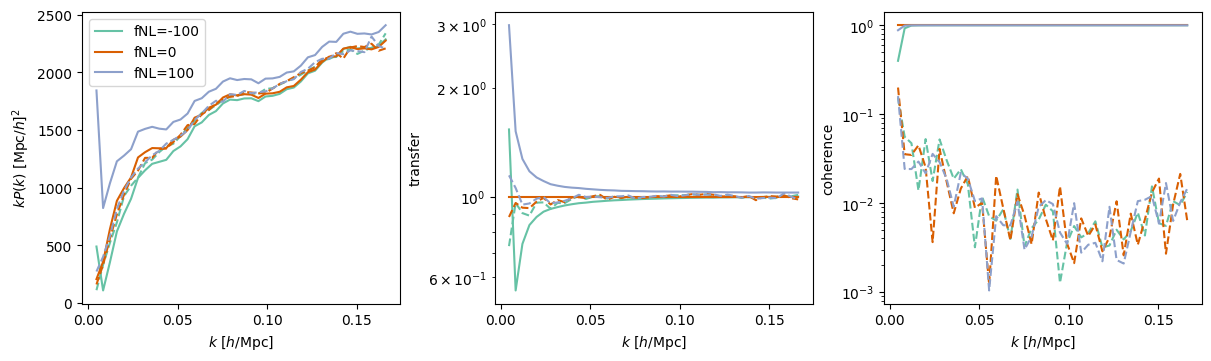

In [19]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

labels = [
    'fNL=-100', 
    'fNL=0', 
    'fNL=100',
    ]
plt.figure(figsize=(12, 3.5), layout="constrained")
for i, (delta_obs, delta_sim) in enumerate(zip(delta_obss, delta_sims)):
    # kptc = model.powtranscoh(delta_obs, delta_sim)
    kptc = model.powtranscoh(delta_sims[1], delta_obs)
    kptc2 = model.powtranscoh(delta_sims[1], delta_sim)
    # kpow = model.spectrum(delta_obs)

    plt.subplot(131)
    # plot_pow(*kpow, f'--C{i}',label=labels[i])
    plot_powtranscoh(*kptc2, f'C{i}', log=log, label=labels[i])
    plot_powtranscoh(*kptc, f'--C{i}', log=log)
plt.subplot(131)
plt.legend()

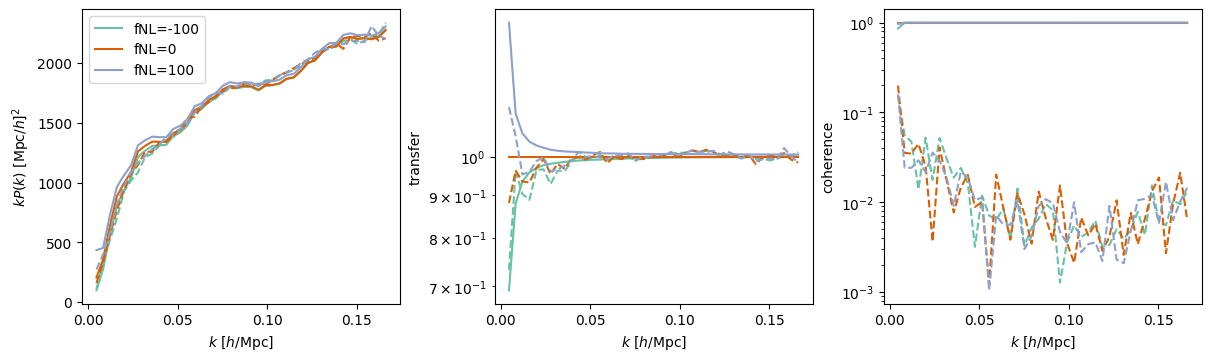

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

labels = [
    'fNL=-100', 
    'fNL=0', 
    'fNL=100',
    ]
plt.figure(figsize=(12, 3.5), layout="constrained")
for i, (delta_obs, delta_sim) in enumerate(zip(delta_obss, delta_sims)):
    # kptc = model.powtranscoh(delta_obs, delta_sim)
    kptc = model.powtranscoh(delta_sims[1], delta_obs)
    kptc2 = model.powtranscoh(delta_sims[1], delta_sim)
    # kpow = model.spectrum(delta_obs)

    plt.subplot(131)
    # plot_pow(*kpow, f'--C{i}',label=labels[i])
    plot_powtranscoh(*kptc2, f'C{i}', log=log, label=labels[i])
    plot_powtranscoh(*kptc, f'--C{i}', log=log)
plt.subplot(131)
plt.legend()

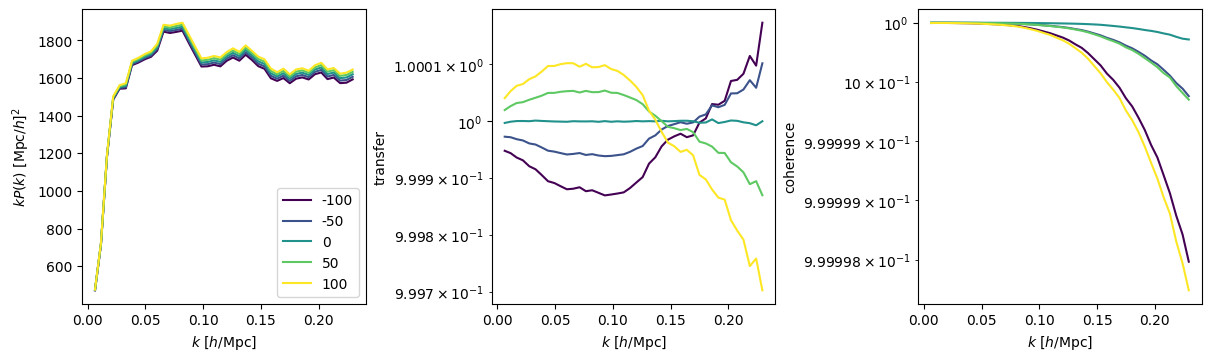

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kptcs)))
for i_plot, (kptc, kptc2) in enumerate(zip(kptcs, kptcs2)):
    kptct = model.powtranscoh(kptc, kptc2)
    plot_powtranscoh(*kptct, log=log, label=values[i_plot], color=colors[i_plot])
plt.subplot(131)
plt.legend()

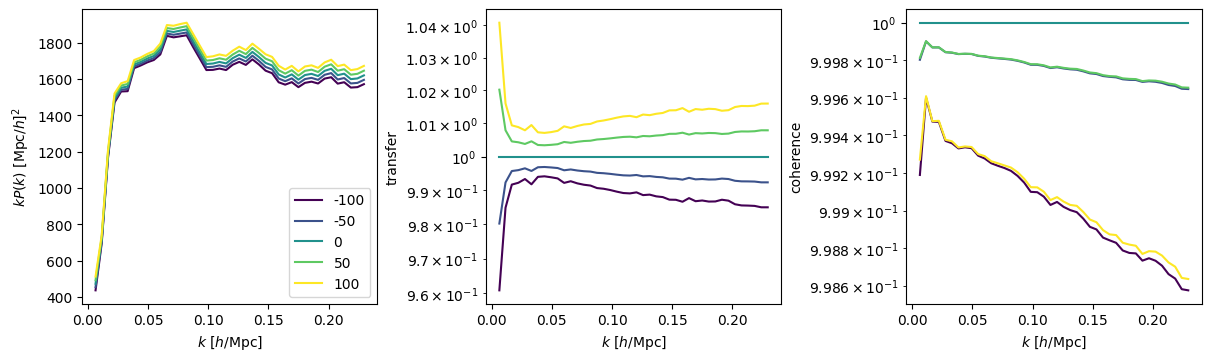

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kptcs)))
for i_plot, kptc in enumerate(kptcs):
    plot_powtranscoh(*kptc, log=log, label=values[i_plot], color=colors[i_plot])
plt.subplot(131)
plt.legend()

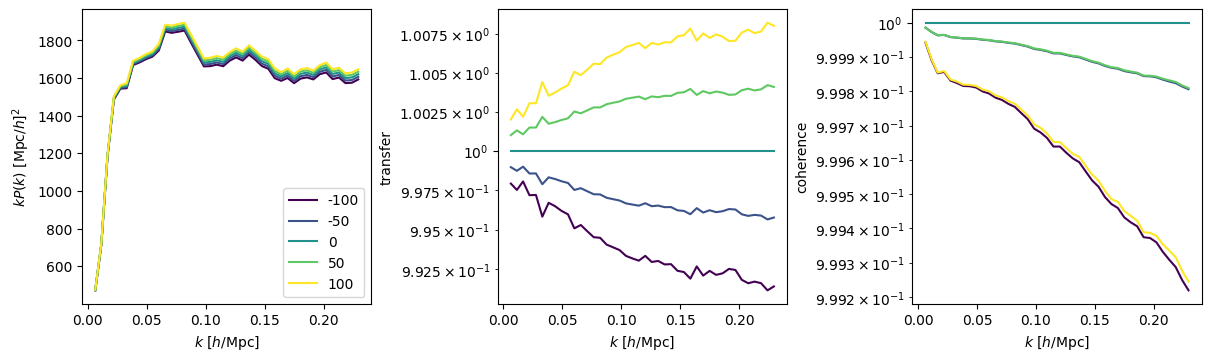

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kptcs)))
for i_plot, kptc in enumerate(kptcs):
    plot_powtranscoh(*kptc, log=log, label=values[i_plot], color=colors[i_plot])
plt.subplot(131)
plt.legend()

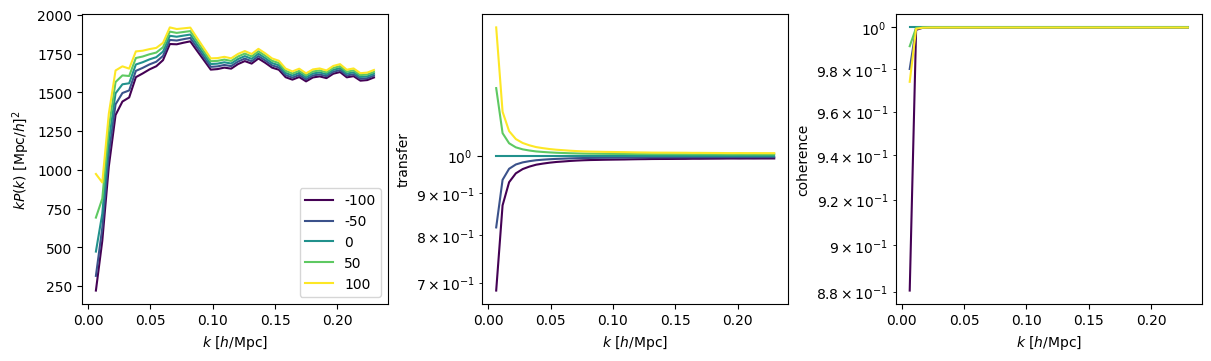

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kptcs)))
for i_plot, kptc in enumerate(kptcs):
    plot_powtranscoh(*kptc, log=log, label=values[i_plot], color=colors[i_plot])
plt.subplot(131)
plt.legend()

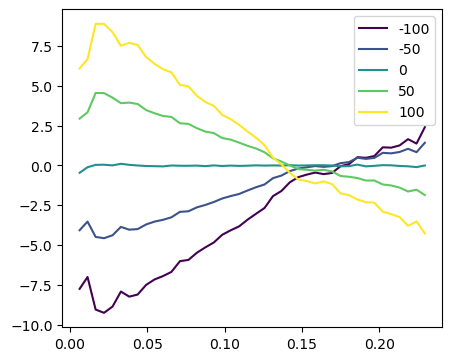

In [5]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kpows)))
for i_plot, (kpow, kpow2) in enumerate(zip(kpows, kpows2)):
    ks = kpow[0]

    plt.plot(ks, kpow[1]-kpow2[1], label=fNL_bp_values[i_plot], color=colors[i_plot])
    # plot_pow(*kpow, log=log, label=fNL_bp_values[i_plot], color=colors[i_plot])
plt.legend()

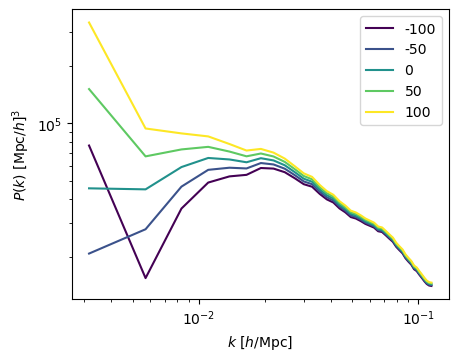

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = True

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
colors = plt.get_cmap('viridis')(np.linspace(0,1,len(kpows)))
for i_plot, kpow in enumerate(kpows):
    plot_pow(*kpow, log=log, label=fNL_bp_values[i_plot], color=colors[i_plot])
plt.legend()

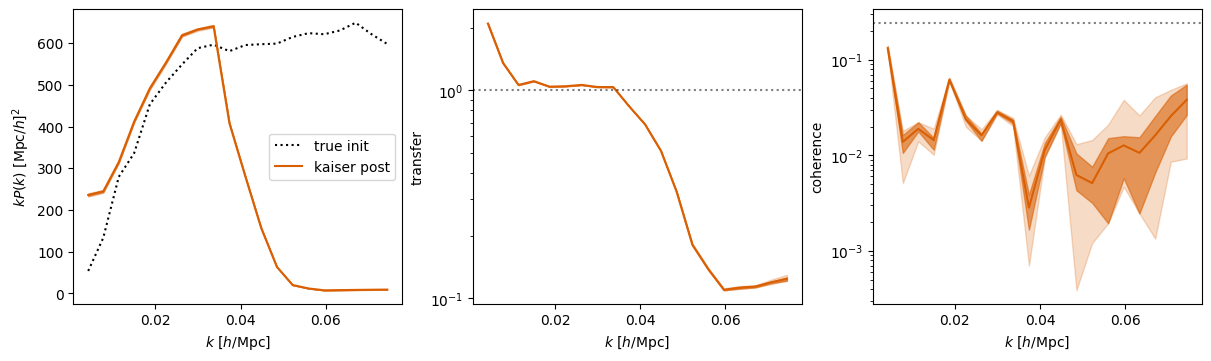

In [ ]:
delta_init0 = jnp.fft.irfftn(truth0['init_mesh'])
delta_init1 = jnp.fft.irfftn(truth1['init_mesh'])
params_start_ = jit(vmap(partial(model.kaiser_post, delta_obs=delta_obs0, scale_field=1.)))(jr.split(jr.key(45), 20)) 
delta_init2 = vmap(lambda x: jnp.fft.irfftn(model.reparam(x)['init_mesh']))(params_start_)

from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_init0), 'k:', log=log, label="true init")
# kptc1 = model.powtranscoh(delta_init0, delta_init1)
# plot_powtranscoh(*kptc1, log=log, label="prior")
# kptc2 = model.powtranscoh(delta_init0, delta_init2)
kptc2 = vmap(lambda x: model.powtranscoh(delta_init0, x))(delta_init2)
color = 'C1'
plot_powtranscoh(*tree.map(lambda x: jnp.median(x, 0), kptc2), log=log, color=color, label="kaiser post")
plot_powtranscoh(*kptc2, log=log, fill=(0.68,0.95), color=color)
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")

prefix='m32_red_interl2_iosamp1'
MSE fNL=0: 1.94361e-01
mean: 5.47187e-17, std: 6.44261e-01, mesh p.05-.95: [-1.42502902  0.96586771]
mean: 1.19781e-16, std: 4.29464e-01, mesh p.05-.95: [-0.70213508  0.75411452]


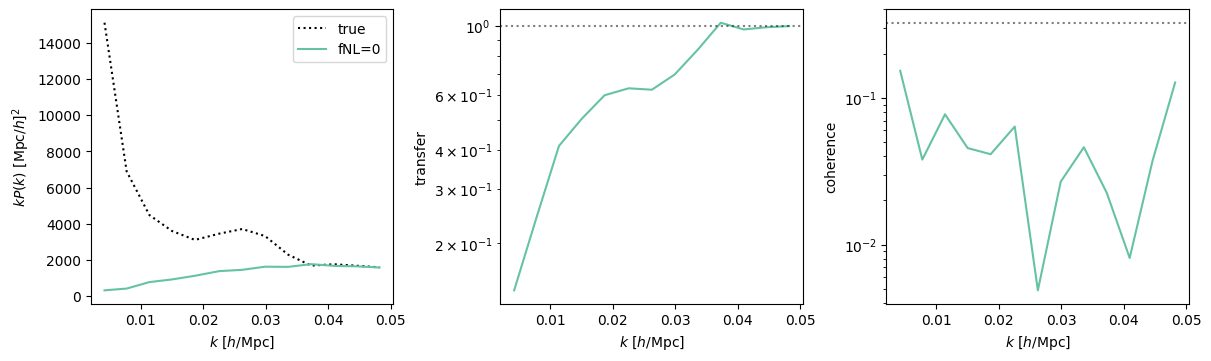

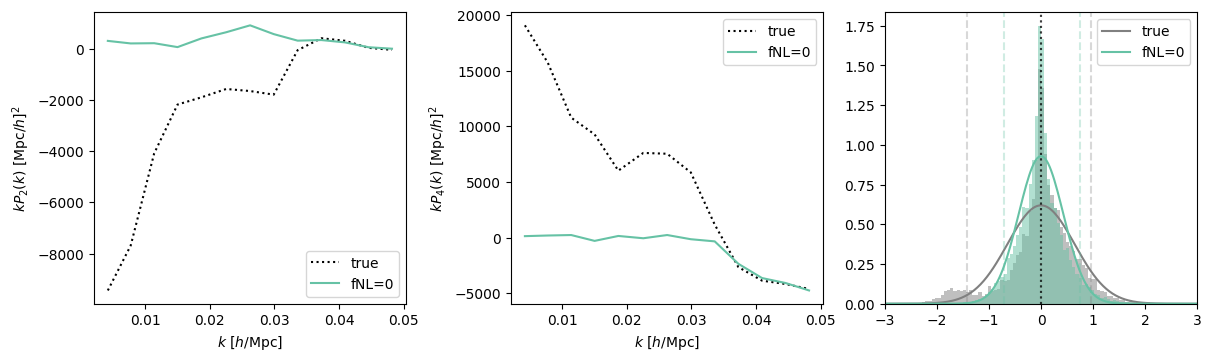

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
from matplotlib import colors
theme(usetex=False)
axis = 0
ids = .1
log = False
# names = ["osamp1.5", 'osamp2']
names = ["fNL=0", 'fNL=50']
# names = ["rect", 'kb']
# names = ["red" 'red2', 'red3']
# names = ["tracer", 'tracer2', 'tracer3']
# names = ["matter", 'matter2', 'matter3']
# names = [
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.00\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.25\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.50\\, k_\\mathrm{final}$",
# ]
# deltas = [delta_obs1, delta_obs2, delta_obs3]
# deltas = [delta_obs1, delta_obs2]
deltas = [delta_det]
prefix = f"m{model.final_shape[0]}_red_interl2_iosamp1"
cmap = None
print(f"{prefix=}")

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="true")
for delta, name in zip(deltas, names):
    kptc = model.powtranscoh(delta_obs0, delta)
    plot_powtranscoh(*kptc, log=log, label=name)
    print(f"MSE {name}: {((delta - delta_obs0)**2).mean():.5e}")
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_real_oversampling_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_redshift_badaxis_oversampling_kptc.png")


plt.figure(figsize=(12, 3.5), layout="constrained")
for i_plt, ell in enumerate((2,4)):
    plt.subplot(1,3,i_plt+1)
    kpow0 = model.spectrum(delta_obs0, poles=(0,2,4))
    plot_pow(*kpow0, 'k:', ell=ell, log=log, label="true")
    for delta, name in zip(deltas, names):
        kpow = model.spectrum(delta, poles=(0,2,4))
        plot_pow(*kpow, ell=ell, log=log, label=name)
    plt.legend()

plt.subplot(1,3,3)
vlim = -3, 3.
# vlim = -2, 2.
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs0, 1e-3)), "true", vlim)
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs1, 1e-3)), "sim", vlim)
plot_pdf(delta_obs0, "true", vlim, color='grey')
for delta, name in zip(deltas, names):
    plot_pdf(delta, name, vlim)
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_pdf.png")

prefix='m96_red_interl2_iosamp1'
MSE fNL=0: 1.25356e+00
mean: 2.22912e-16, std: 1.46163e+00, mesh p.05-.95: [-2.16560814  2.69549713]
mean: 1.96457e-16, std: 1.44975e+00, mesh p.05-.95: [-2.162136    2.65797083]


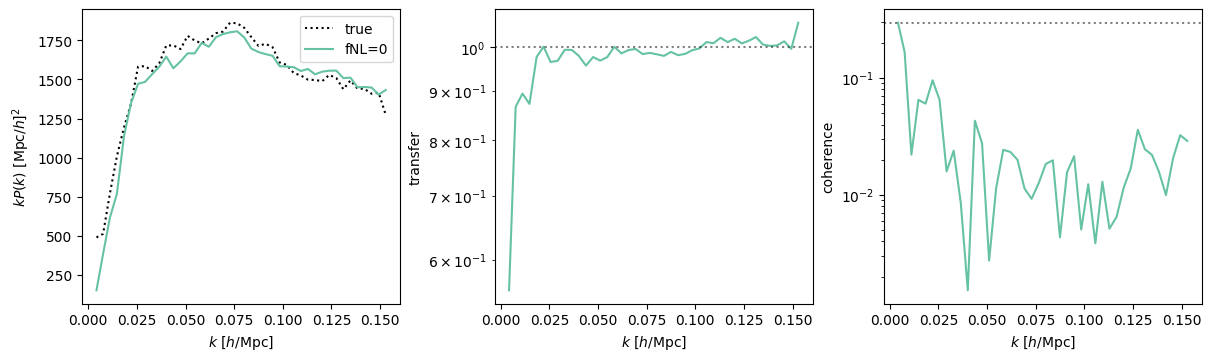

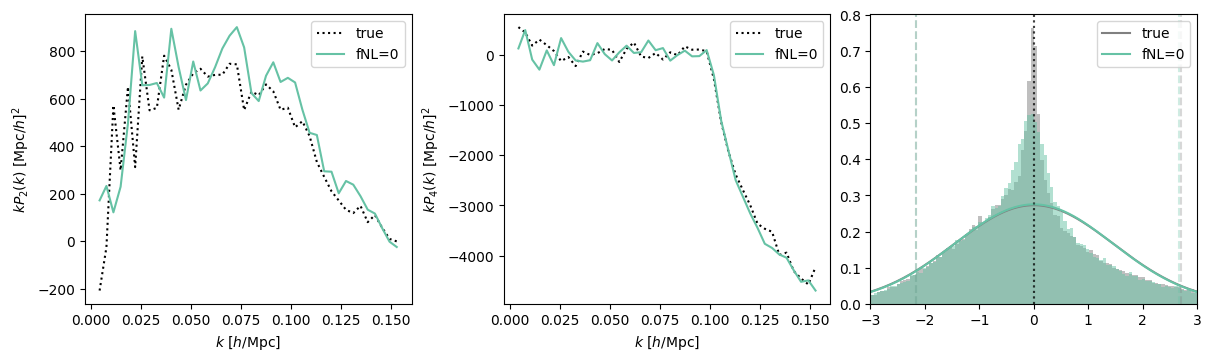

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
from matplotlib import colors
theme(usetex=False)
axis = 0
ids = .1
log = False
# names = ["osamp1.5", 'osamp2']
names = ["fNL=0", 'fNL=50']
# names = ["rect", 'kb']
# names = ["red" 'red2', 'red3']
# names = ["tracer", 'tracer2', 'tracer3']
# names = ["matter", 'matter2', 'matter3']
# names = [
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.00\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.25\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.50\\, k_\\mathrm{final}$",
# ]
# deltas = [delta_obs1, delta_obs2, delta_obs3]
# deltas = [delta_obs1, delta_obs2]
deltas = [delta_det]
prefix = f"m{model.final_shape[0]}_red_interl2_iosamp1"
cmap = None
print(f"{prefix=}")

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="true")
for delta, name in zip(deltas, names):
    kptc = model.powtranscoh(delta_obs0, delta)
    plot_powtranscoh(*kptc, log=log, label=name)
    print(f"MSE {name}: {((delta - delta_obs0)**2).mean():.5e}")
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_real_oversampling_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_redshift_badaxis_oversampling_kptc.png")


plt.figure(figsize=(12, 3.5), layout="constrained")
for i_plt, ell in enumerate((2,4)):
    plt.subplot(1,3,i_plt+1)
    kpow0 = model.spectrum(delta_obs0, poles=(0,2,4))
    plot_pow(*kpow0, 'k:', ell=ell, log=log, label="true")
    for delta, name in zip(deltas, names):
        kpow = model.spectrum(delta, poles=(0,2,4))
        plot_pow(*kpow, ell=ell, log=log, label=name)
    plt.legend()

plt.subplot(1,3,3)
vlim = -3, 3.
# vlim = -2, 2.
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs0, 1e-3)), "true", vlim)
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs1, 1e-3)), "sim", vlim)
plot_pdf(delta_obs0, "true", vlim, color='grey')
for delta, name in zip(deltas, names):
    plot_pdf(delta, name, vlim)
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_pdf.png")

### Plot forward model

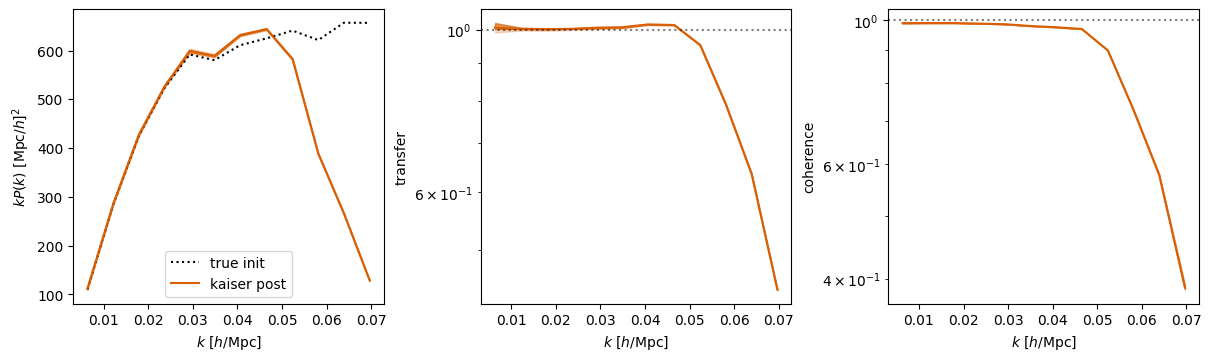

In [10]:
delta_init0 = jnp.fft.irfftn(truth0['init_mesh'])
delta_init1 = jnp.fft.irfftn(truth1['init_mesh'])
params_start_ = jit(vmap(partial(model.kaiser_post, delta_obs=delta_det, scale_field=1.)))(jr.split(jr.key(45), 20)) 
delta_init2 = vmap(lambda x: jnp.fft.irfftn(model.reparam(x)['init_mesh']))(params_start_)

from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
theme(usetex=False)
log = False

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_init0), 'k:', log=log, label="true init")
# kptc1 = model.powtranscoh(delta_init0, delta_init1)
# plot_powtranscoh(*kptc1, log=log, label="prior")
# kptc2 = model.powtranscoh(delta_init0, delta_init2)
kptc2 = vmap(lambda x: model.powtranscoh(delta_init0, x))(delta_init2)
color = 'C1'
plot_powtranscoh(*tree.map(lambda x: jnp.median(x, 0), kptc2), log=log, color=color, label="kaiser post")
plot_powtranscoh(*kptc2, log=log, fill=(0.68,0.95), color=color)
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")

In [34]:
# from montecosmo.plot import plot_mesh
# plt.figure(figsize=(12, 3.5), layout="constrained")
# ids = 0.1
# plt.subplot(131)
# plot_mesh(delta_obs0, ids=ids)
# plt.colorbar()
# plt.subplot(132)
# plot_mesh(delta_obs1, ids=ids)
# plt.colorbar()
# plt.subplot(133)
# plot_mesh(delta_obs1-delta_obs0, ids=ids)
# plt.colorbar() 

def plot_mesh2(masked, ids, axis):
    cmap = 'RdBu_r'
    quad = plot_mesh(model.masked2mesh(masked), box_size, ids, axis, cmap=cmap)
    clim = quad.get_clim()
    norm = colors.TwoSlopeNorm(0., *clim)
    quad = plot_mesh(model.masked2mesh(masked), box_size, ids, axis, cmap=cmap, vlim=None, norm=norm)

def plot_pdf(mesh, label, vlim=1e-2, color=None):
    # mesh = jnp.log10(1+mesh[mesh>1e-2])
    mesh = mesh[mesh != 0]
    print(f"mean: {mesh.mean():.5e}, std: {mesh.std():.5e}, mesh p.05-.95: {np.quantile(mesh, [0.05, 0.95])}")
    if vlim is None:
        vlim = mesh.min(), mesh.max()
    elif isinstance(vlim, float):
        vlim = np.quantile(mesh, [vlim/2, 1-vlim/2])

    from scipy.stats import norm
    x = np.linspace(*vlim, 200)
    pdf = norm.pdf(x, loc=mesh.mean(), scale=mesh.std())
    color = plt.gca()._get_lines.get_next_color() if color is None else color
    plt.plot(x, pdf, label=label, color=color)
    n_hist = np.minimum(100_000, mesh.size)
    plt.hist(jr.choice(jr.key(48), mesh.ravel(), (n_hist,), replace=False), range=vlim, bins=100, density=True, color=color, alpha=0.5)
    plt.axvline(0., color='k', linestyle=':', alpha=0.5)

    q05, q95 = np.quantile(np.asarray(mesh), [0.05, 0.95])
    plt.axvline(q05, color=color, linestyle='--', alpha=0.3)
    plt.axvline(q95, color=color, linestyle='--', alpha=0.3)
    plt.xlim(vlim)
    plt.legend();

prefix='m96_red_interl2_iosamp1'
MSE fNL=0: 3.33488e-01
mean: 1.80218e-16, std: 1.15110e+00, mesh p.05-.95: [-1.46768152  2.16420237]
mean: 4.88935e-17, std: 1.22159e+00, mesh p.05-.95: [-1.50708017  2.29236763]


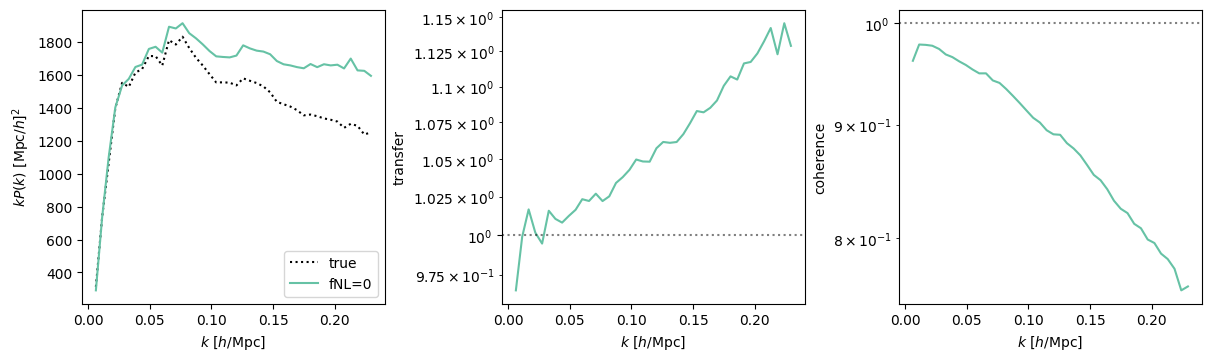

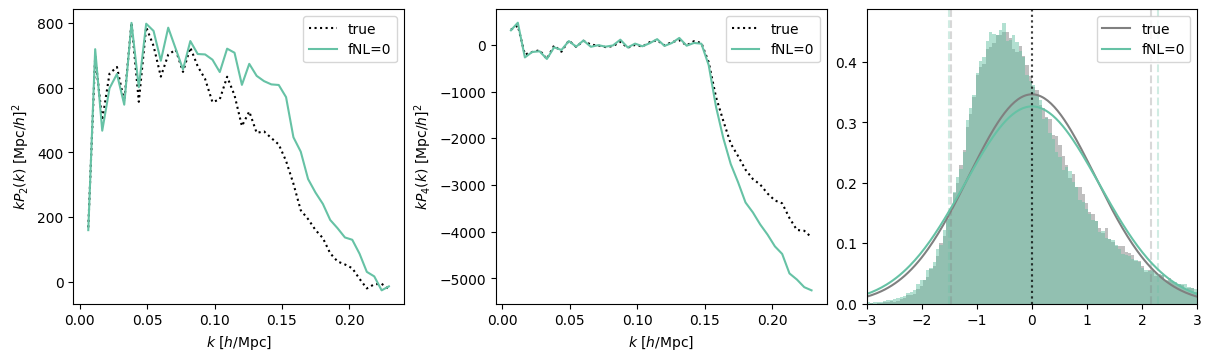

In [35]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
from matplotlib import colors
theme(usetex=False)
axis = 0
ids = .1
log = False
# names = ["osamp1.5", 'osamp2']
names = ["fNL=0", 'fNL=50']
# names = ["rect", 'kb']
# names = ["red" 'red2', 'red3']
# names = ["tracer", 'tracer2', 'tracer3']
# names = ["matter", 'matter2', 'matter3']
# names = [
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.00\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.25\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.50\\, k_\\mathrm{final}$",
# ]
# deltas = [delta_obs1, delta_obs2, delta_obs3]
# deltas = [delta_obs1, delta_obs2]
deltas = [delta_det]
prefix = f"m{model.final_shape[0]}_red_interl2_iosamp1"
cmap = None
print(f"{prefix=}")

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="true")
for delta, name in zip(deltas, names):
    kptc = model.powtranscoh(delta_obs0, delta)
    plot_powtranscoh(*kptc, log=log, label=name)
    print(f"MSE {name}: {((delta - delta_obs0)**2).mean():.5e}")
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_real_oversampling_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_redshift_badaxis_oversampling_kptc.png")


plt.figure(figsize=(12, 3.5), layout="constrained")
for i_plt, ell in enumerate((2,4)):
    plt.subplot(1,3,i_plt+1)
    kpow0 = model.spectrum(delta_obs0, poles=(0,2,4))
    plot_pow(*kpow0, 'k:', ell=ell, log=log, label="true")
    for delta, name in zip(deltas, names):
        kpow = model.spectrum(delta, poles=(0,2,4))
        plot_pow(*kpow, ell=ell, log=log, label=name)
    plt.legend()

plt.subplot(1,3,3)
vlim = -3, 3.
# vlim = -2, 2.
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs0, 1e-3)), "true", vlim)
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs1, 1e-3)), "sim", vlim)
plot_pdf(delta_obs0, "true", vlim, color='grey')
for delta, name in zip(deltas, names):
    plot_pdf(delta, name, vlim)
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_pdf.png")

prefix='m96_red_interl2_iosamp1'
MSE fNL=0: 2.00829e-01
mean: 1.80218e-16, std: 1.15110e+00, mesh p.05-.95: [-1.46768152  2.16420237]
mean: 1.52110e-16, std: 1.16613e+00, mesh p.05-.95: [-1.52042732  2.16750391]


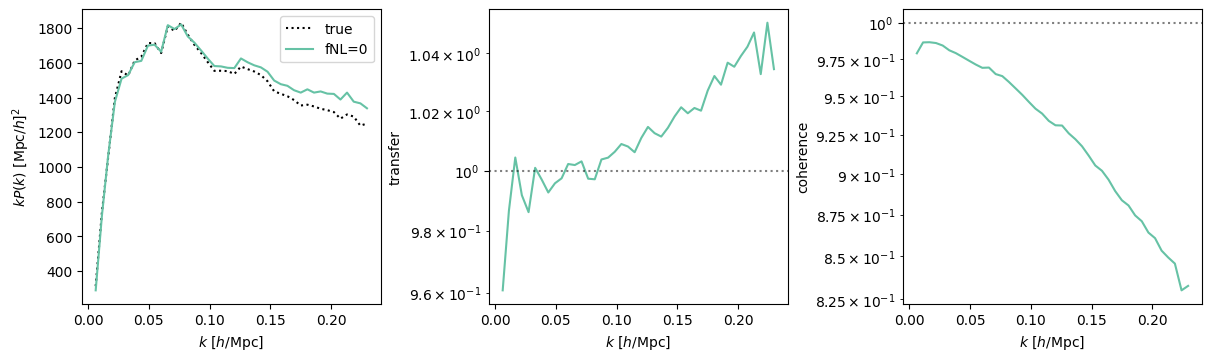

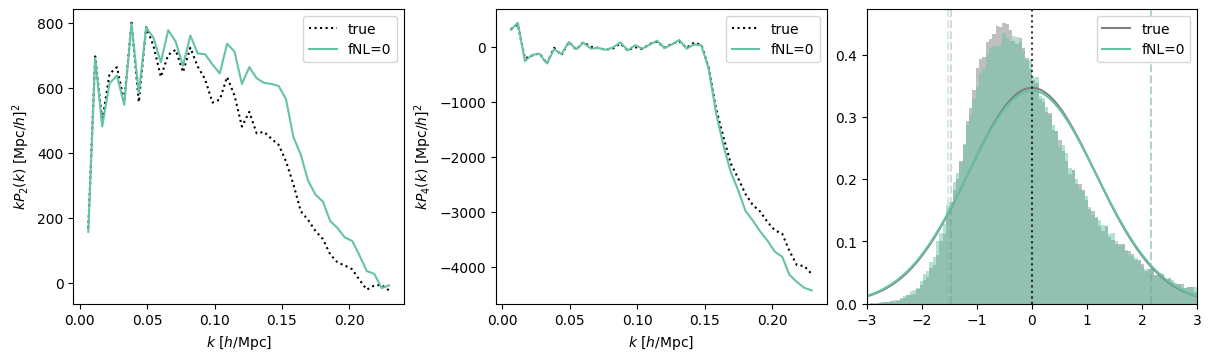

In [ ]:
from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
from matplotlib import colors
theme(usetex=False)
axis = 0
ids = .1
log = False
# names = ["osamp1.5", 'osamp2']
names = ["fNL=0", 'fNL=50']
# names = ["rect", 'kb']
# names = ["red" 'red2', 'red3']
# names = ["tracer", 'tracer2', 'tracer3']
# names = ["matter", 'matter2', 'matter3']
# names = [
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.00\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.25\\, k_\\mathrm{final}$",
#     "$k_\\mathrm{evolve} = k_\\mathrm{paint} = 1.50\\, k_\\mathrm{final}$",
# ]
# deltas = [delta_obs1, delta_obs2, delta_obs3]
# deltas = [delta_obs1, delta_obs2]
deltas = [delta_det]
prefix = f"m{model.final_shape[0]}_red_interl2_iosamp1"
cmap = None
print(f"{prefix=}")

plt.figure(figsize=(12, 3.5), layout="constrained")
plt.subplot(131)
plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="true")
for delta, name in zip(deltas, names):
    kptc = model.powtranscoh(delta_obs0, delta)
    plot_powtranscoh(*kptc, log=log, label=name)
    print(f"MSE {name}: {((delta - delta_obs0)**2).mean():.5e}")
plt.subplot(131)
plt.legend()
plt.subplot(132)
plt.axhline(1., linestyle=':', color='k', alpha=0.5)
plt.subplot(133)
plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_real_oversampling_kptc.png")
# plt.savefig(f"./figs/{prefix}_tracer_redshift_badaxis_oversampling_kptc.png")


plt.figure(figsize=(12, 3.5), layout="constrained")
for i_plt, ell in enumerate((2,4)):
    plt.subplot(1,3,i_plt+1)
    kpow0 = model.spectrum(delta_obs0, poles=(0,2,4))
    plot_pow(*kpow0, 'k:', ell=ell, log=log, label="true")
    for delta, name in zip(deltas, names):
        kpow = model.spectrum(delta, poles=(0,2,4))
        plot_pow(*kpow, ell=ell, log=log, label=name)
    plt.legend()

plt.subplot(1,3,3)
vlim = -3, 3.
# vlim = -2, 2.
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs0, 1e-3)), "true", vlim)
# plot_pdf(jnp.log10(jnp.maximum(1+delta_obs1, 1e-3)), "sim", vlim)
plot_pdf(delta_obs0, "true", vlim, color='grey')
for delta, name in zip(deltas, names):
    plot_pdf(delta, name, vlim)
# plt.savefig(f"./figs/{prefix}_{"_".join(names)}_pdf.png")

### Inspect noise

In [37]:
ob = handlers.seed(pred_lagr_model, 43)()
delta_obs0.mean() /  ob.mean(),  ob.mean(), delta_obs0.mean(), params['ngbars']* model.cell_length**3

(Array(1.006711e-17, dtype=float64),
 Array(7.60742942, dtype=float64),
 Array(7.6584829e-17, dtype=float64),
 Array([7.6082258], dtype=float64))

mean: -2.98517e-17, std: 3.06069e-01, mesh p.05-.95: [-0.48584775  0.50270696]


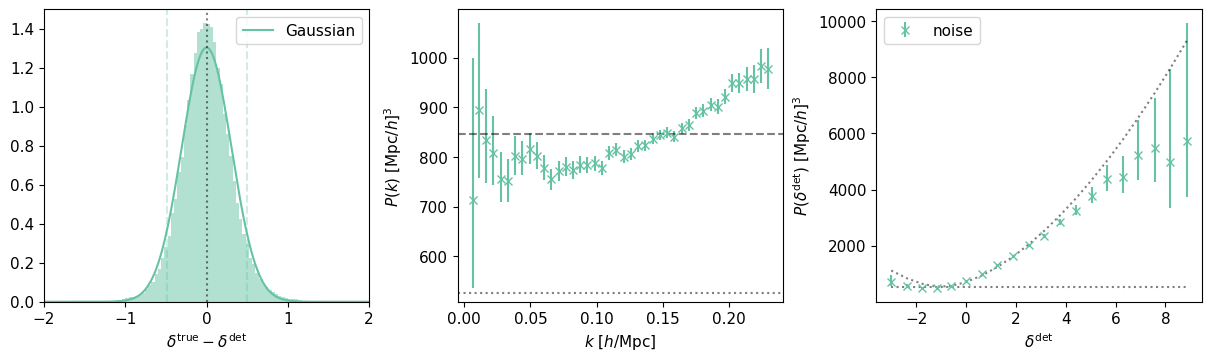

In [ ]:
theme(font_size=11)
from montecosmo.metrics import spectrum_kcount, var_errorbar

pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_ | {'ngbars_':1e12})
delta_det = model.count2delta(handlers.seed(pred_lagr_model, 42)())
######### ngbars_ sigma0
# pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_)
# delta_obs0 = model.count2delta(handlers.seed(pred_lagr_model, 43)())
delta_obs0 = model.count2delta(truth0['obs'])
noise = delta_obs0 - delta_det

# # from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
# # from matplotlib import colors
# theme(usetex=False, font_size=12)
# log = False

# plt.figure(figsize=(12, 3.5), layout="constrained")
# plt.subplot(131)
# plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="tracer")
# kptc1 = model.powtranscoh(delta_obs0, delta_obs1)
# plot_powtranscoh(*kptc1, log=log, label="mode, no noise")
# plt.subplot(131)
# plt.legend()
# plt.subplot(132)
# plt.axhline(1., linestyle=':', color='k', alpha=0.5)
# plt.subplot(133)
# plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);

# plt.savefig(save_dir2 / f"{prefix}_nonkptc.png")
def var_value(tmesh, vmesh, vedges:int|float|list, min_count=5):
    tmesh, vmesh = tmesh.reshape(-1), vmesh.reshape(-1)
    if isinstance(vedges, int):
        n_vedges = vedges
        vmin, vmax = vmesh.min(), vmesh.max()
        dv = (vmax - vmin) / n_vedges
        vedges = np.linspace(vmin, vmax, n_vedges, endpoint=False)
        vedges += dv / 2

    dig = np.digitize(vmesh, vedges)
    vcount = np.bincount(dig)[1:-1]
    vmask = vcount >= min_count
    vcount = vcount[vmask]

    vmean = np.bincount(dig, weights=vmesh)[1:-1]
    vmean = vmean[vmask]
    vmean = vmean / vcount

    tmean = np.bincount(dig, weights=tmesh)[1:-1]
    tmean = tmean[vmask]
    tmean = tmean / vcount

    tvar = np.bincount(dig, weights=tmesh**2)[1:-1]
    tvar = tvar[vmask]
    tvar = tvar / vcount
    tvar = tvar - tmean**2

    return vcount, vmean, tmean, tvar


def plot_noise(noises, delta_obs1, params):
    log = False
    plt.figure(figsize=(12, 3.5), layout="constrained")
    plt.subplot(131)
    # print("noise mean:", noises.mean(), "std:", noises.std())
    # plt.hist(jr.choice(jr.key(48), noises.ravel(), (50000,)), bins=100, density=True)
    # x = np.linspace(noises.min(), noises.max(), 200)
    # from scipy.stats import norm
    # pdf = norm.pdf(x, loc=noises.mean(), scale=noises.std())
    # plt.plot(x, pdf, label="Gaussian")

    vlim = -2., 2.
    plot_pdf(noises, "Gaussian", vlim)
    # plt.xlabel('$\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}$')
    plt.xlabel('$\\delta^\\mathrm{true} - \\delta^\\mathrm{det}$')
    plt.yscale('log') if log else plt.yscale('linear')
    plt.legend()


    plt.subplot(132)
    # plot_pow(*model.spectrum(noises), log=True, label="noise")
    ks, pows = model.spectrum(noises)
    kcount = spectrum_kcount(model.final_shape, model.box_size)
    yerr = var_errorbar(kcount, pows, confidence=0.95)
    plt.errorbar(ks, pows, yerr=yerr, fmt='x', label='noise')

    plt.yscale('log') if log else plt.yscale('linear')
    plt.xscale('log') if log else plt.xscale('linear')
    plt.axhline(params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    plt.axhline(noises.var() * model.cell_length**3, color='k', linestyle='--', alpha=0.5)
    plt.ylabel("$P(k)$ [Mpc/$h$]$^3$")
    plt.xlabel("$k$ [$h$/Mpc]")
    # plt.ylim(bottom=1.7e3)

    plt.subplot(133)
    vcount, vmean, tmean, tvar = var_value(noises * model.cell_length**(3/2), delta_obs1, 30, 20)

    plt.subplot(133)
    yerr = var_errorbar(vcount, tvar, confidence=0.95)
    plt.errorbar(vmean, tvar, yerr=yerr, fmt='x', label='noise')

    # plt.xlabel('$\\bar\\delta^\\mathrm{fit}$')
    # plt.ylabel('$Var[\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}] V_\\mathrm{cell}$ [Mpc/$h$]$^3$')
    plt.xlabel('$\\delta^\\mathrm{det}$')
    plt.ylabel('$P(\\delta^\\mathrm{det})$ [Mpc/$h$]$^3$')
    plt.yscale('log') if log else plt.yscale('linear')


    # plt.ylim(plt.ylim())
    plt.legend(loc='upper left')

    # posit_fn = lambda x: jnp.maximum(x, 1e-9)
    # posit_fn = jnp.abs
    posit_fn = lambda x: jnp.log(1 + jnp.exp(x))
    posit_fn = lambda x: jnp.abs(x)**(1.7)
    # plt.axhline(1 / truth0['sigma_0'], color='k', linestyle=':', alpha=0.5)
    # plt.plot(vmean, posit_fn(1 + params['sigma_delta'] * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle='--', alpha=0.5)
    # plt.plot(vmean, posit_fn(1 + params['sigma_delta']*1.5 * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    plt.plot(vmean, (posit_fn(1 + vmean) *params['sigma_delta'] + params['sigma_0']) / params['ngbars'], color='k', linestyle=':', alpha=0.5)

    plt.plot(vmean, np.ones_like(vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)

plot_noise(noise, delta_det, params)
# plt.savefig(save_dir2 / f"{prefix}_noise.png")

mean: 1.83592e-17, std: 1.08624e-01, mesh p.05-.95: [-0.17682785  0.17946299]


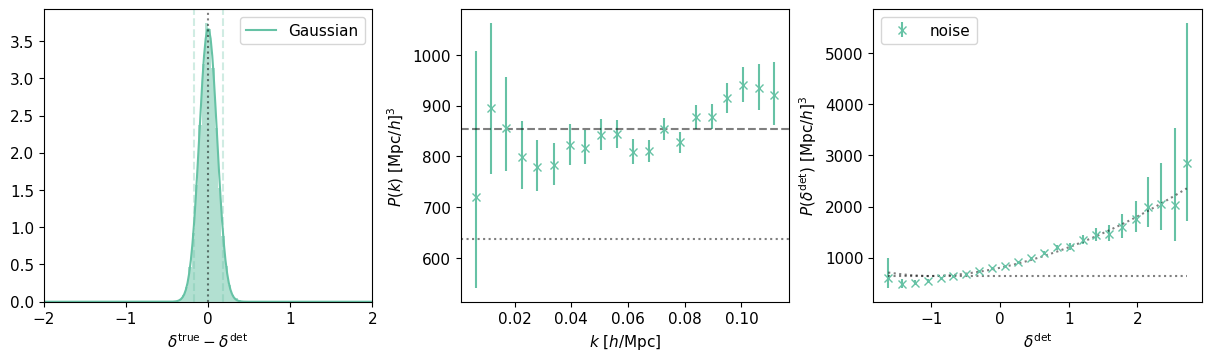

In [ ]:
theme(font_size=11)
from montecosmo.metrics import spectrum_kcount, var_errorbar

pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_ | {'ngbars_':1e12})
delta_det = model.count2delta(handlers.seed(pred_lagr_model, 42)())
######### ngbars_ sigma0
# pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_)
# delta_obs0 = model.count2delta(handlers.seed(pred_lagr_model, 43)())
delta_obs0 = model.count2delta(truth0['obs'])
noise = delta_obs0 - delta_det

# # from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
# # from matplotlib import colors
# theme(usetex=False, font_size=12)
# log = False

# plt.figure(figsize=(12, 3.5), layout="constrained")
# plt.subplot(131)
# plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="tracer")
# kptc1 = model.powtranscoh(delta_obs0, delta_obs1)
# plot_powtranscoh(*kptc1, log=log, label="mode, no noise")
# plt.subplot(131)
# plt.legend()
# plt.subplot(132)
# plt.axhline(1., linestyle=':', color='k', alpha=0.5)
# plt.subplot(133)
# plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);

# plt.savefig(save_dir2 / f"{prefix}_nonkptc.png")
def var_value(tmesh, vmesh, vedges:int|float|list, min_count=5):
    tmesh, vmesh = tmesh.reshape(-1), vmesh.reshape(-1)
    if isinstance(vedges, int):
        n_vedges = vedges
        vmin, vmax = vmesh.min(), vmesh.max()
        dv = (vmax - vmin) / n_vedges
        vedges = np.linspace(vmin, vmax, n_vedges, endpoint=False)
        vedges += dv / 2

    dig = np.digitize(vmesh, vedges)
    vcount = np.bincount(dig)[1:-1]
    vmask = vcount >= min_count
    vcount = vcount[vmask]

    vmean = np.bincount(dig, weights=vmesh)[1:-1]
    vmean = vmean[vmask]
    vmean = vmean / vcount

    tmean = np.bincount(dig, weights=tmesh)[1:-1]
    tmean = tmean[vmask]
    tmean = tmean / vcount

    tvar = np.bincount(dig, weights=tmesh**2)[1:-1]
    tvar = tvar[vmask]
    tvar = tvar / vcount
    tvar = tvar - tmean**2

    return vcount, vmean, tmean, tvar


def plot_noise(noises, delta_obs1, params):
    log = False
    plt.figure(figsize=(12, 3.5), layout="constrained")
    plt.subplot(131)
    # print("noise mean:", noises.mean(), "std:", noises.std())
    # plt.hist(jr.choice(jr.key(48), noises.ravel(), (50000,)), bins=100, density=True)
    # x = np.linspace(noises.min(), noises.max(), 200)
    # from scipy.stats import norm
    # pdf = norm.pdf(x, loc=noises.mean(), scale=noises.std())
    # plt.plot(x, pdf, label="Gaussian")

    vlim = -2., 2.
    plot_pdf(noises, "Gaussian", vlim)
    # plt.xlabel('$\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}$')
    plt.xlabel('$\\delta^\\mathrm{true} - \\delta^\\mathrm{det}$')
    plt.yscale('log') if log else plt.yscale('linear')
    plt.legend()


    plt.subplot(132)
    # plot_pow(*model.spectrum(noises), log=True, label="noise")
    ks, pows = model.spectrum(noises)
    kcount = spectrum_kcount(model.final_shape, model.box_size)
    yerr = var_errorbar(kcount, pows, confidence=0.95)
    plt.errorbar(ks, pows, yerr=yerr, fmt='x', label='noise')

    plt.yscale('log') if log else plt.yscale('linear')
    plt.xscale('log') if log else plt.xscale('linear')
    plt.axhline(params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    plt.axhline(noises.var() * model.cell_length**3, color='k', linestyle='--', alpha=0.5)
    plt.ylabel("$P(k)$ [Mpc/$h$]$^3$")
    plt.xlabel("$k$ [$h$/Mpc]")
    # plt.ylim(bottom=1.7e3)

    plt.subplot(133)
    vcount, vmean, tmean, tvar = var_value(noises * model.cell_length**(3/2), delta_obs1, 30, 20)

    plt.subplot(133)
    yerr = var_errorbar(vcount, tvar, confidence=0.95)
    plt.errorbar(vmean, tvar, yerr=yerr, fmt='x', label='noise')

    # plt.xlabel('$\\bar\\delta^\\mathrm{fit}$')
    # plt.ylabel('$Var[\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}] V_\\mathrm{cell}$ [Mpc/$h$]$^3$')
    plt.xlabel('$\\delta^\\mathrm{det}$')
    plt.ylabel('$P(\\delta^\\mathrm{det})$ [Mpc/$h$]$^3$')
    plt.yscale('log') if log else plt.yscale('linear')


    # plt.ylim(plt.ylim())
    plt.legend(loc='upper left')

    # posit_fn = lambda x: jnp.maximum(x, 1e-9)
    # posit_fn = jnp.abs
    posit_fn = lambda x: jnp.log(1 + jnp.exp(x))
    posit_fn = lambda x: jnp.abs(x)**(1.8)
    # plt.axhline(1 / truth0['sigma_0'], color='k', linestyle=':', alpha=0.5)
    # plt.plot(vmean, posit_fn(1 + params['sigma_delta'] * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle='--', alpha=0.5)
    # plt.plot(vmean, posit_fn(1 + params['sigma_delta']*1.5 * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    plt.plot(vmean, (posit_fn(1 + vmean) *params['sigma_delta'] + params['sigma_0']) / params['ngbars'], color='k', linestyle=':', alpha=0.5)

    plt.plot(vmean, np.ones_like(vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)

plot_noise(noise, delta_det, params)
# plt.savefig(save_dir2 / f"{prefix}_noise.png")

mean: -1.09496e-16, std: 3.04111e-01, mesh p.05-.95: [-0.49653037  0.49521814]


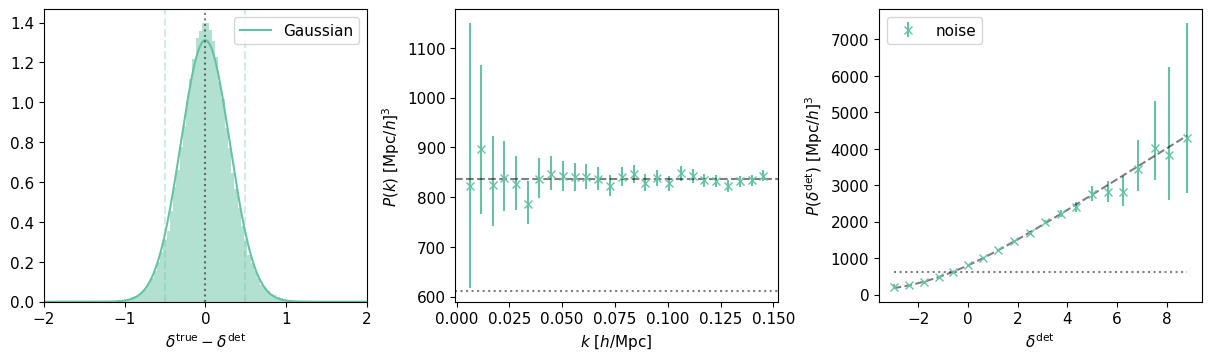

In [ ]:
theme(font_size=11)
from montecosmo.metrics import spectrum_kcount, var_errorbar

pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_ | {'ngbars_':1e12})
delta_det = model.count2delta(handlers.seed(pred_lagr_model, 42)())
######### ngbars_ sigma0
# pred_lagr_model = handlers.condition(lagr_model, data={k:v for k,v in data.items() if k != "obs"} | params_)
# delta_obs0 = model.count2delta(handlers.seed(pred_lagr_model, 43)())
delta_obs0 = model.count2delta(truth0['obs'])
noise = delta_obs0 - delta_det

# # from montecosmo.plot import plot_mesh, plot_pow, plot_powtranscoh, theme
# # from matplotlib import colors
# theme(usetex=False, font_size=12)
# log = False

# plt.figure(figsize=(12, 3.5), layout="constrained")
# plt.subplot(131)
# plot_pow(*model.spectrum(delta_obs0), 'k:', log=log, label="tracer")
# kptc1 = model.powtranscoh(delta_obs0, delta_obs1)
# plot_powtranscoh(*kptc1, log=log, label="mode, no noise")
# plt.subplot(131)
# plt.legend()
# plt.subplot(132)
# plt.axhline(1., linestyle=':', color='k', alpha=0.5)
# plt.subplot(133)
# plt.axhline(model.selec_mesh.mean(), linestyle=':', color='k', alpha=0.5);

# plt.savefig(save_dir2 / f"{prefix}_nonkptc.png")
def var_value(tmesh, vmesh, vedges:int|float|list, min_count=5):
    tmesh, vmesh = tmesh.reshape(-1), vmesh.reshape(-1)
    if isinstance(vedges, int):
        n_vedges = vedges
        vmin, vmax = vmesh.min(), vmesh.max()
        dv = (vmax - vmin) / n_vedges
        vedges = np.linspace(vmin, vmax, n_vedges, endpoint=False)
        vedges += dv / 2

    dig = np.digitize(vmesh, vedges)
    vcount = np.bincount(dig)[1:-1]
    vmask = vcount >= min_count
    vcount = vcount[vmask]

    vmean = np.bincount(dig, weights=vmesh)[1:-1]
    vmean = vmean[vmask]
    vmean = vmean / vcount

    tmean = np.bincount(dig, weights=tmesh)[1:-1]
    tmean = tmean[vmask]
    tmean = tmean / vcount

    tvar = np.bincount(dig, weights=tmesh**2)[1:-1]
    tvar = tvar[vmask]
    tvar = tvar / vcount
    tvar = tvar - tmean**2

    return vcount, vmean, tmean, tvar


def plot_noise(noises, delta_obs1, params):
    log = False
    plt.figure(figsize=(12, 3.5), layout="constrained")
    plt.subplot(131)
    # print("noise mean:", noises.mean(), "std:", noises.std())
    # plt.hist(jr.choice(jr.key(48), noises.ravel(), (50000,)), bins=100, density=True)
    # x = np.linspace(noises.min(), noises.max(), 200)
    # from scipy.stats import norm
    # pdf = norm.pdf(x, loc=noises.mean(), scale=noises.std())
    # plt.plot(x, pdf, label="Gaussian")

    vlim = -2., 2.
    plot_pdf(noises, "Gaussian", vlim)
    # plt.xlabel('$\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}$')
    plt.xlabel('$\\delta^\\mathrm{true} - \\delta^\\mathrm{det}$')
    plt.yscale('log') if log else plt.yscale('linear')
    plt.legend()


    plt.subplot(132)
    # plot_pow(*model.spectrum(noises), log=True, label="noise")
    ks, pows = model.spectrum(noises)
    kcount = spectrum_kcount(model.final_shape, model.box_size)
    yerr = var_errorbar(kcount, pows, confidence=0.95)
    plt.errorbar(ks, pows, yerr=yerr, fmt='x', label='noise')

    plt.yscale('log') if log else plt.yscale('linear')
    plt.xscale('log') if log else plt.xscale('linear')
    plt.axhline(params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    plt.axhline(noises.var() * model.cell_length**3, color='k', linestyle='--', alpha=0.5)
    plt.ylabel("$P(k)$ [Mpc/$h$]$^3$")
    plt.xlabel("$k$ [$h$/Mpc]")
    # plt.ylim(bottom=1.7e3)

    plt.subplot(133)
    vcount, vmean, tmean, tvar = var_value(noises * model.cell_length**(3/2), delta_obs1, 30, 20)

    plt.subplot(133)
    yerr = var_errorbar(vcount, tvar, confidence=0.95)
    plt.errorbar(vmean, tvar, yerr=yerr, fmt='x', label='noise')

    # plt.xlabel('$\\bar\\delta^\\mathrm{fit}$')
    # plt.ylabel('$Var[\\delta^\\mathrm{true} - \\bar\\delta^\\mathrm{fit}] V_\\mathrm{cell}$ [Mpc/$h$]$^3$')
    plt.xlabel('$\\delta^\\mathrm{det}$')
    plt.ylabel('$P(\\delta^\\mathrm{det})$ [Mpc/$h$]$^3$')
    plt.yscale('log') if log else plt.yscale('linear')


    # plt.ylim(plt.ylim())
    plt.legend(loc='upper left')

    # posit_fn = lambda x: jnp.maximum(x, 1e-9)
    # posit_fn = jnp.abs
    posit_fn = lambda x: jnp.log(1 + jnp.exp(x))
    # posit_fn = lambda x: jnp.abs(x)**(1.8)
    # plt.axhline(1 / truth0['sigma_0'], color='k', linestyle=':', alpha=0.5)
    plt.plot(vmean, posit_fn(1 + params['sigma_delta'] * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle='--', alpha=0.5)
    # plt.plot(vmean, posit_fn(1 + params['sigma_delta']*1.5 * vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)
    # plt.plot(vmean, (posit_fn(1 + vmean) * 0.1 + params['sigma_0']) / params['ngbars'], color='k', linestyle=':', alpha=0.5)

    plt.plot(vmean, np.ones_like(vmean) * params['sigma_0'] / params['ngbars'], color='k', linestyle=':', alpha=0.5)

plot_noise(noise, delta_det, params)
# plt.savefig(save_dir2 / f"{prefix}_noise.png")

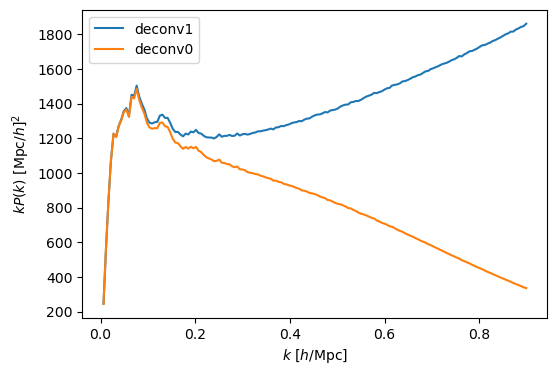

(Array(3.91776232e-17, dtype=float64),)

In [ ]:
# delta_obs0 = jnp.load(load_dir / f'tracer_6746545_paint2_deconv1_{576}.npy') - 1

from montecosmo.plot import plot_mesh, plot_pow, theme
from montecosmo.metrics import spectrum
from montecosmo.nbody import rectangular_hat, deconv_paint, rfftk


kvec = rfftk(delta_obs0.shape)
delta_det = jnp.fft.rfftn(delta_obs0)
delta_det *= rectangular_hat(kvec, order=2)
delta_det = jnp.fft.irfftn(delta_det)


box_size = np.array(3*(2000,))  # Mpc/h
kpow0 = spectrum(delta_obs0, box_size=box_size)
kpow1 = spectrum(delta_det, box_size=box_size)

plt.figure(figsize=(6,4))
plot_pow(*kpow0, label='deconv1')
plot_pow(*kpow1, label='deconv0')
plt.legend()
plt.show()
delta_obs0.mean(), 

In [ ]:
model.reset()
params_ = dict(jnp.load(save_dir / f'params_mode_{model.mesh_shape[0]}.npz'))
print("Final params:\n", params_, '\n', model.reparam(params_))
truth1 = model.predict(samples=truth | params_ | {'ngbars':1000}, hide_base=False, hide_samp=False, from_base=True)
delta_det = truth1['obs']

Final params:
 {'b1_': array(11.76061254), 'b2_': array(2.53433619), 'bn2_': array(0.69443178), 'bs2_': array(-3.26317035)} 
 {'b1': Array(1.11760613, dtype=float64), 'b2': Array(0.25343362, dtype=float64), 'bs2': Array(-0.32631704, dtype=float64), 'bn2': Array(0.69443178, dtype=float64)}


## Lapprox

In [ ]:
from jax.example_libraries.optimizers import adam
from tqdm import tqdm
lr0 = 1.
n_epochs = 500
energies = []

lr_fn = lambda i: lr0 / (1 + i)**.5
opt_init, opt_update, get_params = adam(lr_fn)
opt_state = opt_init(params_start_)
# opt_state = opt_init(params)

def step(step, opt_state):
    value, pot_grad = potential_valgrad(get_params(opt_state))
    opt_state = opt_update(step, pot_grad, opt_state)
    return value, opt_state

for i_epoch in tqdm(range(n_epochs)):
    value, opt_state = step(i_epoch, opt_state)
    energies.append(float(value))
params_ = get_params(opt_state)
jnp.savez(save_dir / f'params_mode_{model.mesh_shape[0]}.npz', **params_)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [01:08<00:00,  7.29it/s]


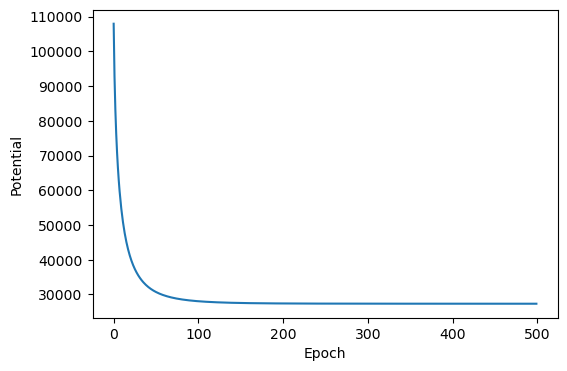

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(energies)
plt.xlabel("Epoch"), plt.ylabel("Potential")
plt.show()

Chains(data={'b2': Array(0.18354903, dtype=float64), 'b1': Array(1.2183641, dtype=float64), 'bn2': Array(-22.77584076, dtype=float64), 'bs2': Array(0.01984765, dtype=float64)}, groups={}, labels={})


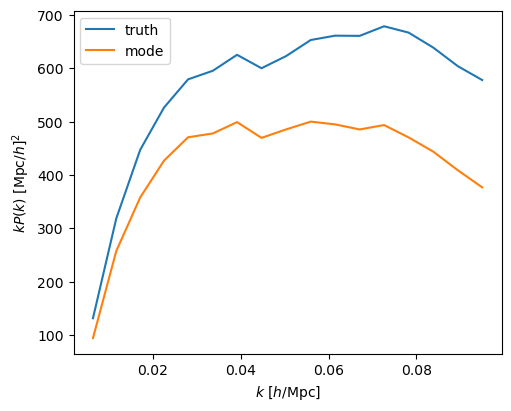

In [ ]:
from montecosmo.chains import Chains
params_ = dict(jnp.load(save_dir / f'params_mode_{model.mesh_shape[0]}.npz'))
post_mode = Chains(model.reparam(params_))
theta_mode, init_mode = post_mode[['*~init_mesh'],'init_mesh']
print(theta_mode)
plt.figure(figsize=(5, 4), layout="constrained")
plot_pow(*model.spectrum(truth['init_mesh']), label='truth')
plot_pow(*model.spectrum(init_mode), label='mode')
plt.legend();

In [ ]:
from montecosmo.chains import Chains
from montecosmo.lapprox import cov_x_from_pot_x_y

theta, tmesh = Chains(params_)[['*~init_mesh_'],['init_mesh_']]
(theta, unravel), (tmesh, _) = theta.ravel(0), tmesh.ravel(0)
names = list(unravel(theta).keys())
labels = [model.labels[k] for k in names]

def pot_fn(theta, mesh):
    params = unravel(theta) | {"init_mesh_": mesh}
    return model.potential(params.data)

cov_x, schur = cov_x_from_pot_x_y(pot_fn, theta, tmesh, method='hutchinson', chunk_size=128)
jnp.save(save_dir / f'cov_mode_{model.mesh_shape[0]}.npy', cov_x)
jnp.save(save_dir / f'schur_mode_{model.mesh_shape[0]}.npy', schur)
print(jnp.linalg.eigvalsh(cov_x))

[-1.11442354e-03  7.03347360e-03  1.42559890e-02  7.91406757e+00]


/feynman/work/dphp/hs276503/envs/montenvtest3/lib/python3.12/site-packages/getdist/gaussian_mixtures.py:39: RuntimeWarning: invalid value encountered in sqrt
  self.norms = (2 * np.pi) ** (0.5 * self.dim) * np.array([np.sqrt(np.linalg.det(cov)) for cov in self.covs])


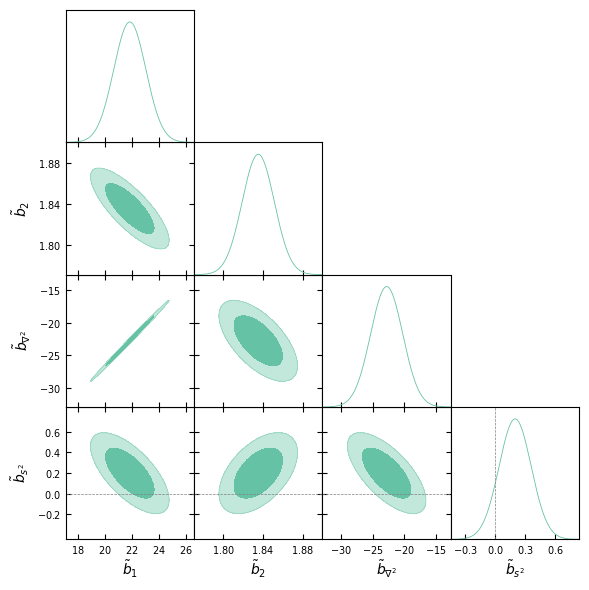

In [ ]:
%matplotlib inline
from getdist import plots, gaussian_mixtures
from montecosmo.plot import SetDark2

gd_fisher = gaussian_mixtures.GaussianND(theta, cov_x, names=names, labels=labels, label='Full Lapprox')
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot(gd_fisher, 
                filled=True, 
                contour_colors=[SetDark2(0)], 
                markers=truth)

In [ ]:
n_chains = 2
model.reset()
truth2 = model.predict(samples=(2,30), hide_base=True, hide_samp=True, from_base=True)

In [ ]:
batch_ndim = 2
theta = Chains(truth2, model.groups_)[['*~init_mesh_','~init_mesh','~obs']]
out, unravel = theta.ravel(1)
print(theta.shape)
print(out.shape)
print(unravel(out).shape)

{'Omega_m_': (2, 30), 'alpha_ap_': (2, 30), 'alpha_iso_': (2, 30), 'b1_': (2, 30), 'b2_': (2, 30), 'bn2_': (2, 30), 'bnp_': (2, 30), 'bs2_': (2, 30), 'fNL_': (2, 30), 'ngbars_': (2, 30, 1), 'sigma8_': (2, 30)}
(2, 330)
{'Omega_m_': (2, 30), 'alpha_ap_': (2, 30), 'alpha_iso_': (2, 30), 'b1_': (2, 30), 'b2_': (2, 30), 'bn2_': (2, 30), 'bnp_': (2, 30), 'bs2_': (2, 30), 'fNL_': (2, 30), 'ngbars_': (2, 30, 1), 'sigma8_': (2, 30)}


Removed no burn in


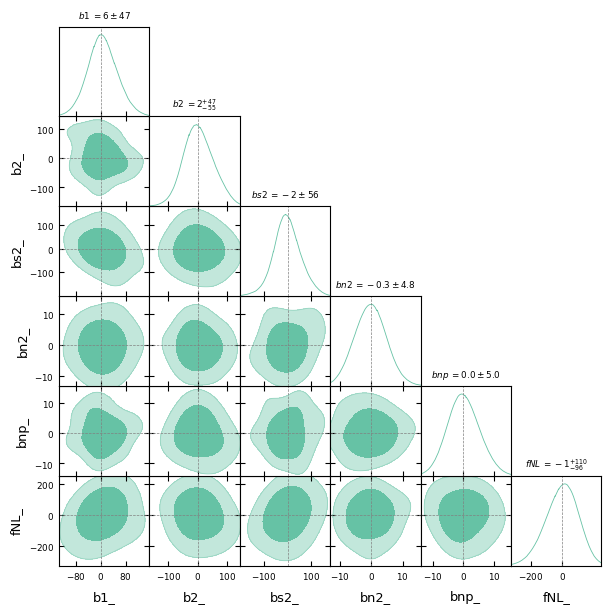

In [ ]:
from getdist import plots
from montecosmo.plot import SetDark2
gdsamp = theta[['bias_']].to_getdist()
gdplt = plots.get_subplot_plotter(width_inch=7)
gdplt.triangle_plot(roots=[gdsamp],
                title_limit=1,
                filled=True, 
                markers=truth,
                contour_colors=[SetDark2(0)],)